In [1]:
!pip install -q "accelerate>=1.1.0" transformers

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

!pip install -q transformers timm evaluate pycocotools torchmetrics albumentations roboflow

import torch

print("=" * 55)
print("KIỂM TRA GPU")
print("=" * 55)
print(f"CUDA available     : {torch.cuda.is_available()}")
print(f"Số lượng GPU       : {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"GPU đang dùng      : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version       : {torch.version.cuda}")
    print(f"VRAM tổng          : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("⚠️  Không tìm thấy GPU!")
print("=" * 55)

KIỂM TRA GPU
CUDA available     : True
Số lượng GPU       : 1
GPU đang dùng      : NVIDIA A40
CUDA version       : 12.8
VRAM tổng          : 44.4 GB


In [2]:
import os
import json
import glob
from roboflow import Roboflow

# ====================== TẢI DATASET TỪ ROBOFLOW ======================
rf = Roboflow(api_key="7cluP5yURKpTZxVV8Wh0")

project = rf.workspace("material-identification").project("garbage-classification-3")
dataset = project.version(2).download("coco")

print(f"✅ Dataset đã tải về tại: {dataset.location}")

BASE_DIR = dataset.location

TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train")
VAL_IMG_DIR   = os.path.join(BASE_DIR, "valid")
TEST_IMG_DIR  = os.path.join(BASE_DIR, "test")

def find_ann_file(default_path, folder):
    if os.path.exists(default_path):
        return default_path
    jsons = glob.glob(os.path.join(folder, "*.json"))
    if jsons:
        print(f"⚠️ Không thấy _annotations.coco.json, dùng: {jsons[0]}")
        return jsons[0]
    raise FileNotFoundError(f"Không tìm thấy file annotation trong {folder}")

TRAIN_ANN_FILE = find_ann_file(os.path.join(TRAIN_IMG_DIR, "_annotations.coco.json"), TRAIN_IMG_DIR)
VAL_ANN_FILE   = find_ann_file(os.path.join(VAL_IMG_DIR, "_annotations.coco.json"), VAL_IMG_DIR)
TEST_ANN_FILE  = find_ann_file(os.path.join(TEST_IMG_DIR, "_annotations.coco.json"), TEST_IMG_DIR)

print(f"Train ann: {TRAIN_ANN_FILE}")
print(f"Val ann  : {VAL_ANN_FILE}")
print(f"Test ann : {TEST_ANN_FILE}")

# ====================== ĐỌC ANNOTATION ======================
with open(TRAIN_ANN_FILE, 'r') as f:
    train_coco = json.load(f)
with open(VAL_ANN_FILE, 'r') as f:
    val_coco = json.load(f)
with open(TEST_ANN_FILE, 'r') as f:
    test_coco = json.load(f)

# ====================== REMAP CLASS ======================
categories = train_coco['categories']
print("\nOriginal categories:")
for cat in categories:
    print(f"  id={cat['id']} → {cat['name']}")

valid_categories = [cat for cat in categories if cat['name'] != "GARBAGE-GARBAGE-CLASSIFICATION"]

old_id_to_new_id = {cat['id']: i for i, cat in enumerate(valid_categories)}
id2label = {i: cat['name'] for i, cat in enumerate(valid_categories)}
label2id = {cat['name']: i for i, cat in enumerate(valid_categories)}

print(f"\n✅ Đã remap thành {len(id2label)} classes:")
for new_id, name in id2label.items():
    print(f"  {new_id}: {name}")

# ====================== THỐNG KÊ ======================
n_train_imgs = len(train_coco['images'])
n_val_imgs   = len(val_coco['images'])
n_test_imgs  = len(test_coco['images'])
total_imgs   = n_train_imgs + n_val_imgs + n_test_imgs

n_train_annos = sum(1 for ann in train_coco['annotations'] if ann['category_id'] in old_id_to_new_id)
n_val_annos   = sum(1 for ann in val_coco['annotations'] if ann['category_id'] in old_id_to_new_id)
n_test_annos  = sum(1 for ann in test_coco['annotations'] if ann['category_id'] in old_id_to_new_id)
total_annos   = n_train_annos + n_val_annos + n_test_annos

print("\n" + "="*60)
print("BẢNG THỐNG KÊ DATASET")
print("="*60)
print(f"{'Tập':<10} | {'Ảnh':<10} | {'Bounding Box':<15} | {'Tỷ lệ'}")
print("-"*60)
print(f"{'Train':<10} | {n_train_imgs:<10} | {n_train_annos:<15} | {n_train_imgs/total_imgs*100:.1f}%")
print(f"{'Valid':<10} | {n_val_imgs:<10} | {n_val_annos:<15} | {n_val_imgs/total_imgs*100:.1f}%")
print(f"{'Test':<10} | {n_test_imgs:<10} | {n_test_annos:<15} | {n_test_imgs/total_imgs*100:.1f}%")
print("-"*60)
print(f"{'TỔNG':<10} | {total_imgs:<10} | {total_annos:<15} | 100.0%")
print("="*60)

loading Roboflow workspace...
loading Roboflow project...
✅ Dataset đã tải về tại: /workspace/GARBAGE-CLASSIFICATION-3-2
Train ann: /workspace/GARBAGE-CLASSIFICATION-3-2/train/_annotations.coco.json
Val ann  : /workspace/GARBAGE-CLASSIFICATION-3-2/valid/_annotations.coco.json
Test ann : /workspace/GARBAGE-CLASSIFICATION-3-2/test/_annotations.coco.json

Original categories:
  id=0 → GARBAGE-GARBAGE-CLASSIFICATION
  id=1 → BIODEGRADABLE
  id=2 → CARDBOARD
  id=3 → GLASS
  id=4 → METAL
  id=5 → PAPER
  id=6 → PLASTIC

✅ Đã remap thành 6 classes:
  0: BIODEGRADABLE
  1: CARDBOARD
  2: GLASS
  3: METAL
  4: PAPER
  5: PLASTIC

BẢNG THỐNG KÊ DATASET
Tập        | Ảnh        | Bounding Box    | Tỷ lệ
------------------------------------------------------------
Train      | 7324       | 51611           | 70.0%
Valid      | 2098       | 18916           | 20.0%
Test       | 1042       | 3563            | 10.0%
------------------------------------------------------------
TỔNG       | 10464      | 

In [3]:
import torch
import torchvision
import numpy as np
from PIL import Image
import albumentations as A
from transformers import AutoImageProcessor

print("Đang tải Image Processor...")
processor = AutoImageProcessor.from_pretrained(
    "SenseTime/deformable-detr",
    size={"shortest_edge": 416, "longest_edge": 416}
)

# ====================== AUGMENTATION ======================
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15, p=0.3),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.2),
], bbox_params=A.BboxParams(
    format='coco',
    label_fields=['category_ids'],
    min_visibility=0.3
))

class CocoDetectionDataset(torchvision.datasets.CocoDetection):
    def __init__(self, img_folder, processor, ann_file, transforms=None):
        super().__init__(img_folder, ann_file)
        self.processor = processor
        self.aug = transforms

    def __getitem__(self, idx):
        img, target = super().__getitem__(idx)
        image_id = self.ids[idx]

        img = np.array(img.convert("RGB"))
        img_h, img_w = img.shape[:2]

        bboxes = []
        category_ids = []

        for ann in target:
            if ann['category_id'] not in old_id_to_new_id:
                continue
            x, y, w, h = ann['bbox']
            if w <= 1 or h <= 1:
                continue
            x = max(0, min(float(x), img_w - 1))
            y = max(0, min(float(y), img_h - 1))
            w = min(float(w), img_w - x)
            h = min(float(h), img_h - y)
            if w <= 1 or h <= 1:
                continue

            bboxes.append([x, y, w, h])
            category_ids.append(old_id_to_new_id[ann['category_id']])

        if self.aug is not None and len(bboxes) > 0:
            try:
                transformed = self.aug(image=img, bboxes=bboxes, category_ids=category_ids)
                img = transformed['image']
                bboxes = transformed['bboxes']
                category_ids = transformed['category_ids']
            except Exception:
                pass

        valid_targets = []
        for bbox, cat_id in zip(bboxes, category_ids):
            valid_targets.append({
                'bbox': list(bbox),
                'category_id': int(cat_id),
                'area': float(bbox[2] * bbox[3]),
                'iscrowd': 0,
                'image_id': image_id
            })

        target_dict = {'image_id': image_id, 'annotations': valid_targets}
        encoding = self.processor(images=img, annotations=target_dict, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze()
        target_out = encoding["labels"][0]

        return pixel_values, target_out

print("Đang khởi tạo Datasets...")
train_dataset = CocoDetectionDataset(TRAIN_IMG_DIR, processor, TRAIN_ANN_FILE, transforms=train_transform)
val_dataset   = CocoDetectionDataset(VAL_IMG_DIR, processor, VAL_ANN_FILE, transforms=None)
test_dataset  = CocoDetectionDataset(TEST_IMG_DIR, processor, TEST_ANN_FILE, transforms=None)

def collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    labels = [item[1] for item in batch]

    max_h = max(img.shape[1] for img in pixel_values)
    max_w = max(img.shape[2] for img in pixel_values)
    batch_size = len(pixel_values)

    padded_pixel_values = torch.zeros((batch_size, 3, max_h, max_w), dtype=torch.float32)
    pixel_mask = torch.zeros((batch_size, max_h, max_w), dtype=torch.long)

    for i, img in enumerate(pixel_values):
        _, h, w = img.shape
        padded_pixel_values[i, :, :h, :w] = img
        pixel_mask[i, :h, :w] = 1

    return {
        'pixel_values': padded_pixel_values,
        'pixel_mask': pixel_mask,
        'labels': labels
    }

print("✅ Dataset sẵn sàng!")

Đang tải Image Processor...
Đang khởi tạo Datasets...
loading annotations into memory...
Done (t=0.15s)
creating index...
index created!
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
✅ Dataset sẵn sàng!


In [4]:
from transformers import DeformableDetrForObjectDetection, TrainingArguments, Trainer
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm
import torch

print("Đang tải mô hình Deformable DETR...")
model = DeformableDetrForObjectDetection.from_pretrained(
    "SenseTime/deformable-detr",
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

class ObjectDetectionTrainer(Trainer):
    def evaluate(self, eval_dataset=None, ignore_keys=None, metric_key_prefix="eval"):
        metrics = super().evaluate(eval_dataset, ignore_keys, metric_key_prefix)
        print(f"\n🔍 Đang tính mAP...")

        metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
        eval_dataloader = self.get_eval_dataloader(eval_dataset)
        self.model.eval()

        with torch.no_grad():
            for batch in tqdm(eval_dataloader, desc="Calculating mAP"):
                pixel_values = batch["pixel_values"].to(self.args.device)
                pixel_mask = batch["pixel_mask"].to(self.args.device)
                labels = [{k: v.to(self.args.device) for k, v in t.items()} for t in batch["labels"]]

                outputs = self.model(pixel_values=pixel_values, pixel_mask=pixel_mask)

                target_sizes = []
                for i, lab in enumerate(labels):
                    if "size" in lab:
                        target_sizes.append(lab["size"].tolist())
                    else:
                        mask = pixel_mask[i]
                        h = (mask.sum(dim=1) > 0).sum().item()
                        w = (mask.sum(dim=0) > 0).sum().item()
                        target_sizes.append([h, w])

                target_sizes_tensor = torch.tensor(target_sizes, device=self.args.device)

                results = processor.post_process_object_detection(
                    outputs,
                    target_sizes=target_sizes_tensor,
                    threshold=0.05
                )

                preds = [{"boxes": r["boxes"], "scores": r["scores"], "labels": r["labels"]} for r in results]

                targets = []
                for lab, (h, w) in zip(labels, target_sizes):
                    boxes = lab["boxes"]
                    boxes = boxes * torch.tensor([w, h, w, h], device=boxes.device)
                    cx, cy, bw, bh = boxes.unbind(-1)
                    xyxy = torch.stack([cx - 0.5*bw, cy - 0.5*bh, cx + 0.5*bw, cy + 0.5*bh], dim=-1)
                    targets.append({"boxes": xyxy, "labels": lab["class_labels"]})

                metric.update(preds, targets)

        map_results = metric.compute()
        mAP = map_results["map"].item()
        metrics[f"{metric_key_prefix}_map"] = mAP
        print(f"🏆 mAP@0.5:0.95 = {mAP*100:.2f}%\n")
        return metrics

# ====================== TRAINING ARGUMENTS TỐI ƯU A40 ======================
training_args = TrainingArguments(
    output_dir="./deformable-detr-garbage",
    seed=1337,

    per_device_train_batch_size=16,             # tăng lên một chút
    gradient_accumulation_steps=1,             # effective batch = 16
    per_device_eval_batch_size=16,

    num_train_epochs=15,                       # ← giảm xuống 15 epoch
    learning_rate=6e-5,
    weight_decay=1e-4,
    lr_scheduler_type="cosine",
    warmup_steps=600,

    optim="adamw_torch",
    bf16=True,

    # Giảm tần suất evaluate để train nhanh hơn
    eval_strategy="steps",
    eval_steps=400,
    save_strategy="steps",
    save_steps=400,
    save_total_limit=3,

    load_best_model_at_end=True,
    metric_for_best_model="eval_map",
    greater_is_better=True,

    remove_unused_columns=False,
    report_to="none",
    logging_steps=50,

    dataloader_num_workers=12,
    dataloader_pin_memory=True,
    dataloader_persistent_workers=True,
)

trainer = ObjectDetectionTrainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

print("🚀 BẮT ĐẦU HUẤN LUYỆN TRÊN A40...")
trainer.train()

# Lưu model tốt nhất
model.save_pretrained("./best_deformable_detr")
processor.save_pretrained("./best_deformable_detr")
print("✅ Đã lưu model tốt nhất tại ./best_deformable_detr")

Đang tải mô hình Deformable DETR...


Loading weights:   0%|          | 0/545 [00:00<?, ?it/s]

[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED | 

🚀 BẮT ĐẦU HUẤN LUYỆN TRÊN A40...


Step,Training Loss,Validation Loss
400,1.554963,1.476486
800,1.451790,1.365733
1200,1.331871,1.319929
1600,1.351731,1.265977
2000,1.240730,1.223250
2400,1.238013,1.231630
2800,1.142729,1.215059
3200,1.153935,1.184675
3600,1.099628,1.140748
4000,1.041997,1.108485


...

🏆 mAP@0.5:0.95 = 25.19%



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.backbone.model.conv1.weight', 'model.backbone.model.bn1.weight', 'model.backbone.model.bn1.bias', 'model.backbone.model.bn1.running_mean', 'model.backbone.model.bn1.running_var', 'model.backbone.model.layer1.0.conv1.weight', 'model.backbone.model.layer1.0.bn1.weight', 'model.backbone.model.layer1.0.bn1.bias', 'model.backbone.model.layer1.0.bn1.running_mean', 'model.backbone.model.layer1.0.bn1.running_var', 'model.backbone.model.layer1.0.conv2.weight', 'model.backbone.model.layer1.0.bn2.weight', 'model.backbone.model.layer1.0.bn2.bias', 'model.backbone.model.layer1.0.bn2.running_mean', 'model.backbone.model.layer1.0.bn2.running_var', 'model.backbone.model.layer1.0.conv3.weight', 'model.backbone.model.layer1.0.bn3.weight', 'model.backbone.model.layer1.0.bn3.bias', 'model.backbone.model.layer1.0.bn3.running_mean', 'model.backbone.model.layer1.0.bn3.running_var', 'model.backbone.model.layer1.0.downsample.0.weigh

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Đã lưu model tốt nhất tại ./best_deformable_detr


In [5]:
import torch
import numpy as np
from tqdm.auto import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import box_iou

# ====================== ĐÁNH GIÁ TRÊN TẬP TEST ======================
EVAL_DATASET = test_dataset
print("🔍 Đang tính metrics trên tập Test...")

model.eval()
device = next(model.parameters()).device

# Metric tính mAP tại nhiều ngưỡng IoU
metric = MeanAveragePrecision(
    box_format="xyxy",
    iou_type="bbox",
    iou_thresholds=[0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95],
    max_detection_thresholds=[1, 10, 100],
    class_metrics=True,
)

eval_dataloader = torch.utils.data.DataLoader(
    EVAL_DATASET,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=8,
    pin_memory=True
)

all_preds = []
all_targets = []

with torch.no_grad():
    for batch in tqdm(eval_dataloader, desc="Infer Test"):
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        # Lấy kích thước thật của ảnh
        target_sizes = []
        for i, lab in enumerate(labels):
            if "size" in lab:
                target_sizes.append(lab["size"].tolist())
            else:
                mask = pixel_mask[i]
                h = (mask.sum(dim=1) > 0).sum().item()
                w = (mask.sum(dim=0) > 0).sum().item()
                target_sizes.append([h, w])

        target_sizes_tensor = torch.tensor(target_sizes, device=device)

        results = processor.post_process_object_detection(
            outputs,
            target_sizes=target_sizes_tensor,
            threshold=0.3          # dùng cho Precision / Recall / F1
        )

        for r in results:
            all_preds.append({
                "boxes": r["boxes"].cpu(),
                "scores": r["scores"].cpu(),
                "labels": r["labels"].cpu()
            })

        for lab, (h, w) in zip(labels, target_sizes):
            boxes = lab["boxes"].cpu()
            boxes = boxes * torch.tensor([w, h, w, h])
            cx, cy, bw, bh = boxes.unbind(-1)
            xyxy = torch.stack([cx - 0.5*bw, cy - 0.5*bh, cx + 0.5*bw, cy + 0.5*bh], dim=-1)

            all_targets.append({
                "boxes": xyxy,
                "labels": lab["class_labels"].cpu()
            })

# ====================== TÍNH mAP ======================
metric.update(all_preds, all_targets)
results = metric.compute()

# ====================== TÍNH Precision / Recall / F1 / Mean Matched IoU ======================
def calculate_prf_and_iou(preds, targets, iou_threshold=0.5):
    tp = 0
    fp = 0
    fn = 0
    matched_ious = []

    for pred, target in zip(preds, targets):
        pred_boxes = pred["boxes"]
        pred_labels = pred["labels"]
        gt_boxes = target["boxes"]
        gt_labels = target["labels"]

        if len(gt_boxes) == 0:
            fp += len(pred_boxes)
            continue
        if len(pred_boxes) == 0:
            fn += len(gt_boxes)
            continue

        ious = box_iou(pred_boxes, gt_boxes)
        matched_gt = set()

        for i in range(len(pred_boxes)):
            max_iou, max_idx = ious[i].max(0)
            max_iou = max_iou.item()
            max_idx = max_idx.item()

            if (max_iou >= iou_threshold and
                max_idx not in matched_gt and
                pred_labels[i] == gt_labels[max_idx]):
                tp += 1
                matched_gt.add(max_idx)
                matched_ious.append(max_iou)
            else:
                fp += 1

        fn += len(gt_boxes) - len(matched_gt)

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    mean_matched_iou = np.mean(matched_ious) if matched_ious else 0.0

    return precision, recall, f1, mean_matched_iou, tp, fp, fn

precision, recall, f1, mean_matched_iou, tp, fp, fn = calculate_prf_and_iou(
    all_preds, all_targets, iou_threshold=0.5
)

# ====================== IN KẾT QUẢ ======================
print("\n" + "="*70)
print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST")
print("="*70)

print(f"\n📊 mAP tổng quát:")
print(f"  mAP@0.50:0.95 : {results['map'].item()*100:.2f}%")
print(f"  mAP@0.50      : {results['map_50'].item()*100:.2f}%")
print(f"  mAP@0.75      : {results['map_75'].item()*100:.2f}%")

print(f"\n📊 mAP tại từng ngưỡng IoU:")
iou_thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
# Torchmetrics không trả trực tiếp map theo từng IoU riêng lẻ dễ lấy,
# nên in các giá trị chính + map tổng
print(f"  mAP@50  : {results['map_50'].item()*100:.2f}%")
print(f"  mAP@75  : {results['map_75'].item()*100:.2f}%")
print(f"  mAP@50:95: {results['map'].item()*100:.2f}%")

print(f"\n📊 Precision / Recall / F1 / IoU (conf=0.3, IoU=0.5):")
print(f"  Precision        : {precision*100:.2f}%")
print(f"  Recall           : {recall*100:.2f}%")
print(f"  F1-Score         : {f1*100:.2f}%")
print(f"  Mean Matched IoU : {mean_matched_iou*100:.2f}%")
print(f"  TP={tp} | FP={fp} | FN={fn}")

print(f"\n📊 mAP theo từng class:")
if "map_per_class" in results and results["map_per_class"] is not None:
    for idx, class_map in enumerate(results["map_per_class"]):
        class_name = id2label.get(idx, f"class_{idx}")
        value = class_map.item() * 100 if not torch.isnan(class_map) else 0.0
        print(f"  {idx:02d} - {class_name:<20}: {value:.2f}%")

print("="*70)
print("✅ Hoàn tất đánh giá trên tập Test!")

🔍 Đang tính metrics trên tập Test...


Infer Test:   0%|          | 0/66 [00:00<?, ?it/s]


KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST

📊 mAP tổng quát:
  mAP@0.50:0.95 : 15.61%
  mAP@0.50      : 20.67%
  mAP@0.75      : 16.52%

📊 mAP tại từng ngưỡng IoU:
  mAP@50  : 20.67%
  mAP@75  : 16.52%
  mAP@50:95: 15.61%

📊 Precision / Recall / F1 / IoU (conf=0.3, IoU=0.5):
  Precision        : 41.99%
  Recall           : 35.04%
  F1-Score         : 38.20%
  Mean Matched IoU : 88.94%
  TP=1248 | FP=1724 | FN=2314

📊 mAP theo từng class:
  00 - BIODEGRADABLE       : 4.42%
  01 - CARDBOARD           : 3.32%
  02 - GLASS               : -100.00%
  03 - METAL               : 30.79%
  04 - PAPER               : 22.08%
  05 - PLASTIC             : 17.45%
✅ Hoàn tất đánh giá trên tập Test!


In [6]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from torchvision.ops import box_iou
import torch

# ====================== CẤU HÌNH ======================
IOU_MATCH = 0.50
CONF_FOR_PRF1 = 0.25
IOU_THRESHOLDS = np.round(np.arange(0.50, 0.96, 0.05), 2)

EVAL_DATASET = test_dataset
print("🔍 Đang chạy inference trên tập Test...")

model.eval()
device = next(model.parameters()).device

eval_dataloader = torch.utils.data.DataLoader(
    EVAL_DATASET,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=8,
    pin_memory=True
)

# ====================== INFERENCE ======================
all_preds = []   # list of dict: boxes (xyxy), scores, labels
all_targets = [] # list of dict: boxes (xyxy), labels

with torch.no_grad():
    for batch in tqdm(eval_dataloader, desc="Infer Test"):
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        target_sizes = []
        for i, lab in enumerate(labels):
            if "size" in lab:
                target_sizes.append(lab["size"].tolist())
            else:
                mask = pixel_mask[i]
                h = (mask.sum(dim=1) > 0).sum().item()
                w = (mask.sum(dim=0) > 0).sum().item()
                target_sizes.append([h, w])

        target_sizes_tensor = torch.tensor(target_sizes, device=device)

        results = processor.post_process_object_detection(
            outputs,
            target_sizes=target_sizes_tensor,
            threshold=0.01          # lấy hết, lọc confidence sau
        )

        for r in results:
            all_preds.append({
                "boxes": r["boxes"].cpu().numpy(),
                "scores": r["scores"].cpu().numpy(),
                "labels": r["labels"].cpu().numpy().astype(int)
            })

        for lab, (h, w) in zip(labels, target_sizes):
            boxes = lab["boxes"].cpu()
            boxes = boxes * torch.tensor([w, h, w, h])
            cx, cy, bw, bh = boxes.unbind(-1)
            xyxy = torch.stack([cx - 0.5*bw, cy - 0.5*bh, cx + 0.5*bw, cy + 0.5*bh], dim=-1)

            all_targets.append({
                "boxes": xyxy.numpy(),
                "labels": lab["class_labels"].cpu().numpy().astype(int)
            })

# ====================== HÀM HỖ TRỢ ======================
def compute_ap(recall, precision):
    if len(recall) == 0:
        return 0.0
    mrec = np.r_[0.0, recall, 1.0]
    mpre = np.r_[1.0, precision, 0.0]
    mpre = np.maximum.accumulate(mpre[::-1])[::-1]
    x = np.linspace(0, 1, 101)
    trapz = getattr(np, "trapezoid", np.trapz)
    return float(trapz(np.interp(x, mrec, mpre), x))

def match_predictions(pred_boxes, pred_scores, pred_labels, gt_boxes, gt_labels, iou_thr, conf_min=None):
    if conf_min is not None:
        keep = pred_scores >= conf_min
        pred_boxes = pred_boxes[keep]
        pred_scores = pred_scores[keep]
        pred_labels = pred_labels[keep]

    # sắp xếp theo score giảm dần
    order = np.argsort(-pred_scores)
    pred_boxes = pred_boxes[order]
    pred_scores = pred_scores[order]
    pred_labels = pred_labels[order]

    tp = np.zeros(len(pred_boxes))
    fp = np.zeros(len(pred_boxes))
    matched_ious = []
    used = np.zeros(len(gt_boxes), dtype=bool)

    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return tp, fp, matched_ious

    ious = box_iou(
        torch.tensor(pred_boxes, dtype=torch.float32),
        torch.tensor(gt_boxes, dtype=torch.float32)
    ).numpy()

    for i in range(len(pred_boxes)):
        # chỉ xét cùng class
        same_class = (gt_labels == pred_labels[i])
        if not same_class.any():
            fp[i] = 1
            continue

        valid_ious = ious[i].copy()
        valid_ious[~same_class] = -1

        best_idx = np.argmax(valid_ious)
        best_iou = valid_ious[best_idx]

        if best_iou >= iou_thr and not used[best_idx]:
            tp[i] = 1
            used[best_idx] = True
            matched_ious.append(best_iou)
        else:
            fp[i] = 1

    return tp, fp, matched_ious

def evaluate_at_iou(iou_thr):
    rows = []
    total_tp = total_fp = total_fn = 0
    all_ious = []
    ap_values = []

    for cid, cname in id2label.items():
        # gom toàn bộ pred + gt của class này
        class_pred_boxes, class_pred_scores, class_pred_labels = [], [], []
        class_gt_boxes, class_gt_labels = [], []
        n_gt = 0

        for pred, target in zip(all_preds, all_targets):
            # predictions
            mask_p = pred["labels"] == cid
            class_pred_boxes.append(pred["boxes"][mask_p])
            class_pred_scores.append(pred["scores"][mask_p])
            class_pred_labels.append(pred["labels"][mask_p])

            # ground truth
            mask_g = target["labels"] == cid
            gt_b = target["boxes"][mask_g]
            class_gt_boxes.append(gt_b)
            class_gt_labels.append(target["labels"][mask_g])
            n_gt += len(gt_b)

        # nối lại
        if n_gt == 0 and sum(len(b) for b in class_pred_boxes) == 0:
            continue

        pred_boxes = np.concatenate(class_pred_boxes) if class_pred_boxes else np.zeros((0, 4))
        pred_scores = np.concatenate(class_pred_scores) if class_pred_scores else np.zeros(0)
        pred_labels = np.concatenate(class_pred_labels) if class_pred_labels else np.zeros(0, dtype=int)
        gt_boxes = np.concatenate(class_gt_boxes) if class_gt_boxes else np.zeros((0, 4))
        gt_labels = np.concatenate(class_gt_labels) if class_gt_labels else np.zeros(0, dtype=int)

        # --- Tính AP (dùng tất cả confidence) ---
        tp_all, fp_all, _ = match_predictions(
            pred_boxes, pred_scores, pred_labels, gt_boxes, gt_labels, iou_thr
        )
        recall_curve = np.cumsum(tp_all) / (n_gt + 1e-9)
        precision_curve = np.cumsum(tp_all) / (np.cumsum(tp_all) + np.cumsum(fp_all) + 1e-9)
        ap = compute_ap(recall_curve, precision_curve) if n_gt > 0 else np.nan

        # --- Tính Precision / Recall / F1 / mean_matched_IoU (lọc theo CONF_FOR_PRF1) ---
        tp_fixed, fp_fixed, matched_ious = match_predictions(
            pred_boxes, pred_scores, pred_labels, gt_boxes, gt_labels,
            iou_thr, conf_min=CONF_FOR_PRF1
        )

        tp = int(tp_fixed.sum())
        fp = int(fp_fixed.sum())
        fn = int(n_gt - tp)

        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1 = 2 * precision * recall / (precision + recall + 1e-9)

        rows.append({
            "class_id": cid,
            "class_name": cname,
            "gt_boxes": n_gt,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "mean_matched_IoU": float(np.mean(matched_ious)) if matched_ious else 0.0,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1,
            "AP": ap,
        })

        if n_gt > 0:
            ap_values.append(ap)
        total_tp += tp
        total_fp += fp
        total_fn += fn
        all_ious.extend(matched_ious)

    # Summary
    precision = total_tp / (total_tp + total_fp + 1e-9)
    recall = total_tp / (total_tp + total_fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    summary = {
        "IoU_threshold": iou_thr,
        "confidence_for_P_R_F1": CONF_FOR_PRF1,
        "mean_matched_IoU": float(np.mean(all_ious)) if all_ious else 0.0,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "mAP": float(np.nanmean(ap_values)) if ap_values else 0.0,
    }

    return pd.DataFrame(rows), summary

# ====================== CHẠY ĐÁNH GIÁ ======================
print("📊 Đang tính metrics...")

per_class_50, summary_50 = evaluate_at_iou(IOU_MATCH)

map_curve = []
for t in IOU_THRESHOLDS:
    _, s = evaluate_at_iou(float(t))
    map_curve.append({"IoU_threshold": float(t), "mAP": s["mAP"]})

map_curve = pd.DataFrame(map_curve)
summary_50["mAP@0.5:0.95_custom"] = map_curve["mAP"].mean()

# ====================== HIỂN THỊ KẾT QUẢ ======================
print("\n" + "="*70)
print("PER-CLASS METRICS (IoU = 0.50)")
print("="*70)
display(per_class_50)

print("\n" + "="*70)
print("SUMMARY METRICS (IoU = 0.50)")
print("="*70)
display(pd.DataFrame([summary_50]))

print("\n" + "="*70)
print("mAP THEO TỪNG NGƯỠNG IoU")
print("="*70)
display(map_curve)

# ====================== LƯU FILE ======================
per_class_50.to_csv("deformable_detr_test_per_class_metrics_iou50.csv", index=False)
pd.DataFrame([summary_50]).to_csv("deformable_detr_test_summary_metrics.csv", index=False)
map_curve.to_csv("deformable_detr_test_map_by_iou.csv", index=False)

print("\n✅ Đã lưu kết quả:")
print("  - deformable_detr_test_per_class_metrics_iou50.csv")
print("  - deformable_detr_test_summary_metrics.csv")
print("  - deformable_detr_test_map_by_iou.csv")

🔍 Đang chạy inference trên tập Test...


Infer Test:   0%|          | 0/66 [00:00<?, ?it/s]

📊 Đang tính metrics...

PER-CLASS METRICS (IoU = 0.50)


,class_id,class_name,gt_boxes,tp,fp,fn,mean_matched_IoU,Precision,Recall,F1-score,AP
0,0,BIODEGRADABLE,49,23,404,26,0.679958,0.053864,0.469388,0.096639,0.112875
1,1,CARDBOARD,20,15,397,5,0.681772,0.036408,0.750000,0.069444,0.343439
2,2,GLASS,0,0,0,0,0.000000,0.000000,0.000000,0.000000,NaN
3,3,METAL,533,377,578,156,0.852145,0.394764,0.707317,0.506720,0.573149
4,4,PAPER,1375,380,472,995,0.904882,0.446009,0.276364,0.341266,0.281031
5,5,PLASTIC,1585,926,628,659,0.813678,0.595882,0.584227,0.589997,0.606707



SUMMARY METRICS (IoU = 0.50)


,IoU_threshold,confidence_for_P_R_F1,mean_matched_IoU,Precision,Recall,F1-score,mAP,mAP@0.5:0.95_custom
0,0.5,0.25,0.839306,0.409762,0.483156,0.443442,0.38344,0.245928



mAP THEO TỪNG NGƯỠNG IoU


,IoU_threshold,mAP
0,0.50,0.383440
1,0.55,0.366508
2,0.60,0.329263
3,0.65,0.306848
4,0.70,0.276595
5,0.75,0.247872
6,0.80,0.213092
7,0.85,0.167347
8,0.90,0.122699
9,0.95,0.045613



✅ Đã lưu kết quả:
  - deformable_detr_test_per_class_metrics_iou50.csv
  - deformable_detr_test_summary_metrics.csv
  - deformable_detr_test_map_by_iou.csv


🔍 Đang tìm confidence threshold tốt nhất cho F1-Score...


Sweep confidence:   0%|          | 0/18 [00:00<?, ?it/s]


KẾT QUẢ QUÉT CONFIDENCE THRESHOLD


,confidence,Precision,Recall,F1-score,mean_matched_IoU,TP,FP,FN
0,0.05,0.056649,0.840539,0.106144,0.794345,2994,49858,568
1,0.10,0.114435,0.806569,0.200433,0.800964,2873,22233,689
2,0.15,0.199089,0.748175,0.314491,0.807815,2665,10721,897
3,0.20,0.305582,0.637844,0.413204,0.819242,2272,5163,1290
4,0.25,0.409762,0.483156,0.443442,0.839306,1721,2479,1841
5,0.30,0.504219,0.335486,0.402900,0.856307,1195,1175,2367
6,0.35,0.546408,0.190062,0.282025,0.862743,677,562,2885
7,0.40,0.521891,0.083661,0.144205,0.871759,298,273,3264
8,0.45,0.420561,0.025267,0.047669,0.883045,90,124,3472
9,0.50,0.307692,0.003369,0.006665,0.825991,12,27,3550



THRESHOLD TỐT NHẤT CHO F1-SCORE
  Best Confidence : 0.25
  Precision       : 40.98%
  Recall          : 48.32%
  F1-Score        : 44.34%
  Mean Matched IoU: 83.93%
  TP=1721 | FP=2479 | FN=1841


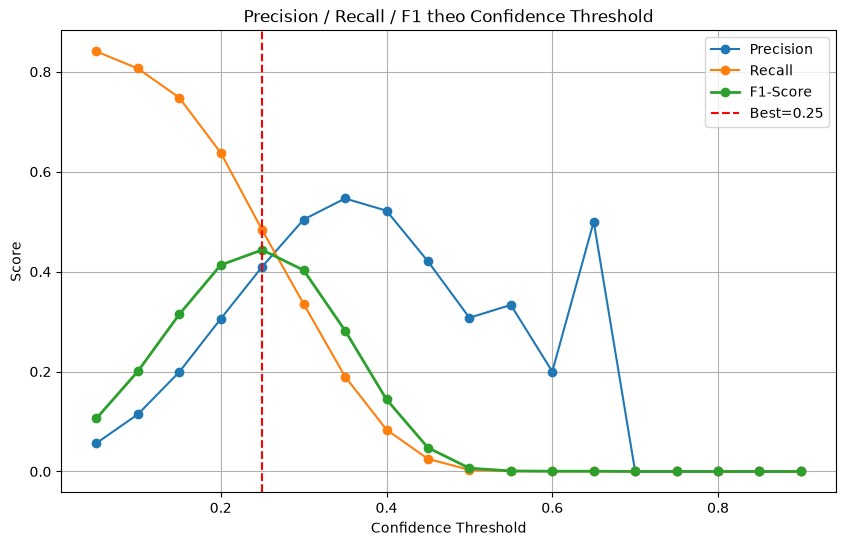


✅ Đã lưu: deformable_detr_threshold_sweep.csv


In [7]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ====================== TÌM THRESHOLD TỐT NHẤT CHO F1 ======================
print("🔍 Đang tìm confidence threshold tốt nhất cho F1-Score...")

# Quét threshold từ 0.05 → 0.90
thresholds = np.round(np.arange(0.05, 0.91, 0.05), 2)

results = []

for conf in tqdm(thresholds, desc="Sweep confidence"):
    total_tp = total_fp = total_fn = 0
    all_ious = []

    for cid in id2label.keys():
        class_pred_boxes, class_pred_scores, class_pred_labels = [], [], []
        class_gt_boxes, class_gt_labels = [], []
        n_gt = 0

        for pred, target in zip(all_preds, all_targets):
            mask_p = pred["labels"] == cid
            class_pred_boxes.append(pred["boxes"][mask_p])
            class_pred_scores.append(pred["scores"][mask_p])
            class_pred_labels.append(pred["labels"][mask_p])

            mask_g = target["labels"] == cid
            gt_b = target["boxes"][mask_g]
            class_gt_boxes.append(gt_b)
            class_gt_labels.append(target["labels"][mask_g])
            n_gt += len(gt_b)

        pred_boxes = np.concatenate(class_pred_boxes) if class_pred_boxes else np.zeros((0, 4))
        pred_scores = np.concatenate(class_pred_scores) if class_pred_scores else np.zeros(0)
        pred_labels = np.concatenate(class_pred_labels) if class_pred_labels else np.zeros(0, dtype=int)
        gt_boxes = np.concatenate(class_gt_boxes) if class_gt_boxes else np.zeros((0, 4))
        gt_labels = np.concatenate(class_gt_labels) if class_gt_labels else np.zeros(0, dtype=int)

        # Dùng hàm match_predictions đã có sẵn (IoU = 0.5)
        tp_fixed, fp_fixed, matched_ious = match_predictions(
            pred_boxes, pred_scores, pred_labels,
            gt_boxes, gt_labels,
            iou_thr=0.5,
            conf_min=conf
        )

        tp = int(tp_fixed.sum())
        fp = int(fp_fixed.sum())
        fn = int(n_gt - tp)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        all_ious.extend(matched_ious)

    precision = total_tp / (total_tp + total_fp + 1e-9)
    recall = total_tp / (total_tp + total_fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    mean_iou = float(np.mean(all_ious)) if all_ious else 0.0

    results.append({
        "confidence": conf,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "mean_matched_IoU": mean_iou,
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn
    })

df_thresh = pd.DataFrame(results)

# ====================== TÌM THRESHOLD TỐT NHẤT ======================
best_idx = df_thresh["F1-score"].idxmax()
best_row = df_thresh.loc[best_idx]

print("\n" + "="*70)
print("KẾT QUẢ QUÉT CONFIDENCE THRESHOLD")
print("="*70)
display(df_thresh)

print("\n" + "="*70)
print("THRESHOLD TỐT NHẤT CHO F1-SCORE")
print("="*70)
print(f"  Best Confidence : {best_row['confidence']:.2f}")
print(f"  Precision       : {best_row['Precision']*100:.2f}%")
print(f"  Recall          : {best_row['Recall']*100:.2f}%")
print(f"  F1-Score        : {best_row['F1-score']*100:.2f}%")
print(f"  Mean Matched IoU: {best_row['mean_matched_IoU']*100:.2f}%")
print(f"  TP={int(best_row['TP'])} | FP={int(best_row['FP'])} | FN={int(best_row['FN'])}")
print("="*70)

# ====================== VẼ BIỂU ĐỒ ======================
plt.figure(figsize=(10, 6))
plt.plot(df_thresh["confidence"], df_thresh["Precision"], label="Precision", marker='o')
plt.plot(df_thresh["confidence"], df_thresh["Recall"], label="Recall", marker='o')
plt.plot(df_thresh["confidence"], df_thresh["F1-score"], label="F1-Score", marker='o', linewidth=2)
plt.axvline(best_row["confidence"], color='red', linestyle='--', label=f"Best={best_row['confidence']:.2f}")
plt.xlabel("Confidence Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 theo Confidence Threshold")
plt.legend()
plt.grid(True)
plt.show()

# Lưu kết quả
df_thresh.to_csv("deformable_detr_threshold_sweep.csv", index=False)
print("\n✅ Đã lưu: deformable_detr_threshold_sweep.csv")